In [ ]:
from google.colab import files
uploaded = files.upload()

Saving creditcard.csv to creditcard (2).csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

#loading the Credit Card data which I got from kaggle

data = pd.read_csv('creditcard.csv')

print("Dataset Loaded Successfully")
print(data.head())

Dataset Loaded Successfully
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

    

In [ ]:
#Checking Dataset Information
#data shape = (rows, columns)
print("Dataset Shape:")
print(data.shape)

print("Missing Value: ")
print(data.isnull().sum())

Dataset Shape:
(284807, 31)
Missing Value: 
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [ ]:
#checking class distribution
print("Class Distribution:")
print(data['Class'].value_counts())

Class Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


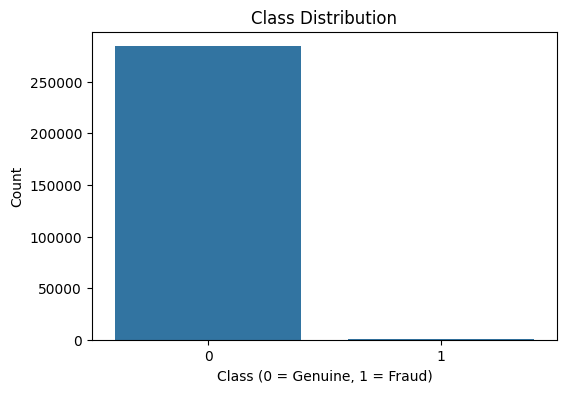

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Class', data=data)
plt.title("Class Distribution")
plt.xlabel("Class (0 = Genuine, 1 = Fraud)")
plt.ylabel("Count")
plt.show()

In [ ]:
#separating geunine and fraud transaction
#Genuine Transcation = 0
#Fraud Transaction = 1
genuine = data[data.Class == 0]
fraud = data[data.Class == 1]

print("Genuine Transaction:")
print(genuine.shape)
print("Fraud Transaction:")
print(fraud.shape)

Genuine Transaction:
(284315, 31)
Fraud Transaction:
(492, 31)


In [ ]:
#Balancing dataset using Undersampling
#Undersampling = because of reducing the majority class
geunine_sample = genuine.sample(n=len(fraud))
new_dataset = pd.concat([geunine_sample, fraud], axis=0)
new_dataset.head()

print("Balanced Dataset:")
print(new_dataset["Class"].value_counts())

Balanced Dataset:
Class
0    492
1    492
Name: count, dtype: int64


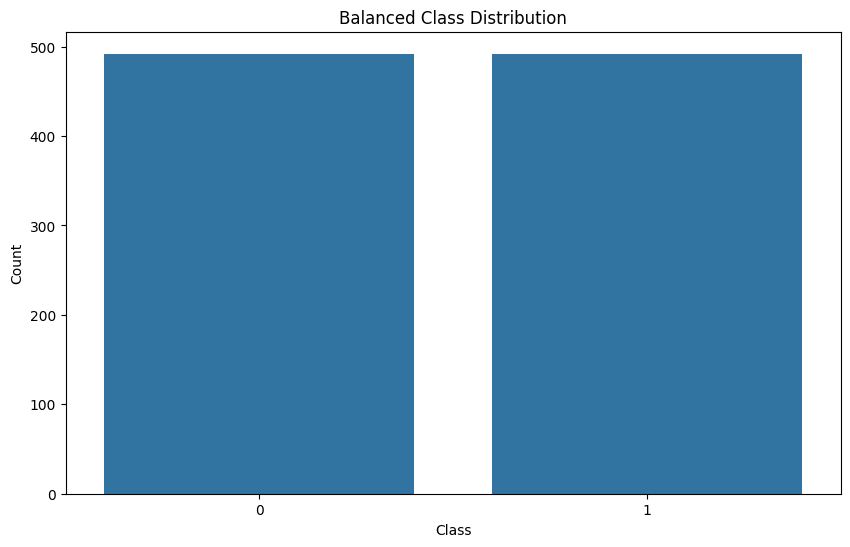

In [ ]:
plt.figure(figsize=(10, 6))
sns.countplot(x='Class', data=new_dataset)
plt.title("Balanced Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [ ]:
#splitting features and target
#input data = features
#output data = target
X = new_dataset.drop(columns="Class", axis=1)
y = new_dataset["Class"]

#Training and Testing split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=2)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (787, 30)
X_test shape: (197, 30)
y_train shape: (787,)
y_test shape: (197,)


In [ ]:
#training model by using Logistic Regression

model = LogisticRegression()
model.fit(X_train, y_train)

print("Model Training Completed")

Model Training Completed


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
#making prediction
y_pred = model.predict(X_test)

#evaluating the model
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Model Evaluation: ")
print("Accuracy Score:", accuracy)
print("Precision Score:", precision)
print("Recall Score:", recall)
print("F1 Score:", f1)
print("Confusion Matrix:",cm)

Model Evaluation: 
Accuracy Score: 0.934010152284264
Precision Score: 0.9775280898876404
Recall Score: 0.8877551020408163
F1 Score: 0.93048128342246
Confusion Matrix: [[97  2]
 [11 87]]


In [ ]:
#testing with one sample transaction
sample = X_test.iloc[0].values.reshape(1, -1)
prediction = model.predict(sample)
if prediction[0] == 0:
  print("Genuine Transaction")
else:
  print("Fraud Transaction")

Fraud Transaction


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
